In [10]:
!pip install networkx==2.8.8


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install scikit-fuzzy
# Libraries
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Evaluación de la calidad de un producto dado su sabor, defectos y sabor.

Size of the fruit (300-600g): 400
Defects area pf the piece of fruits (0-20cm2): 10.0
Fruit flavor (0-1): 0.5
Fruit quality (between 1 and 4):  3.61


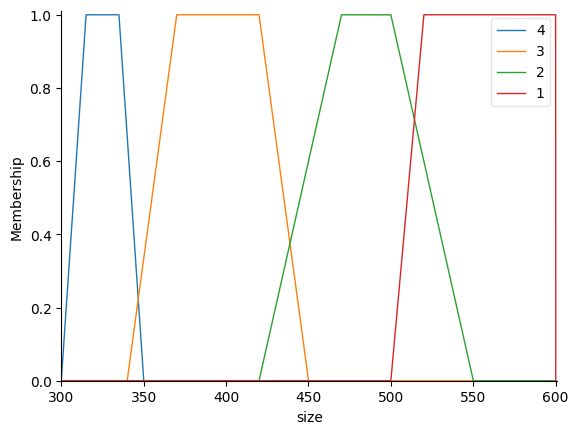

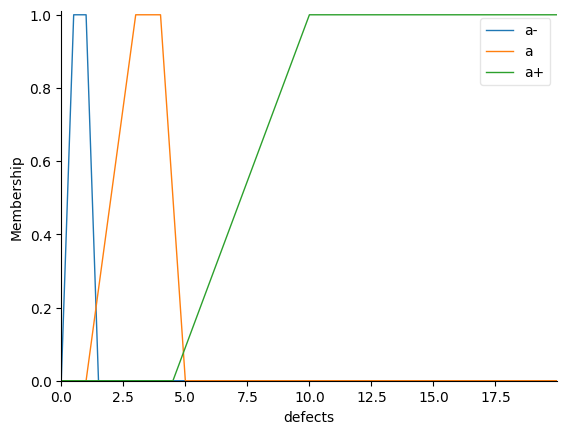

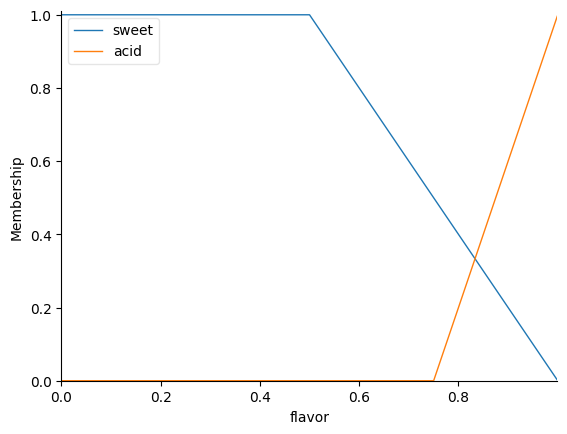

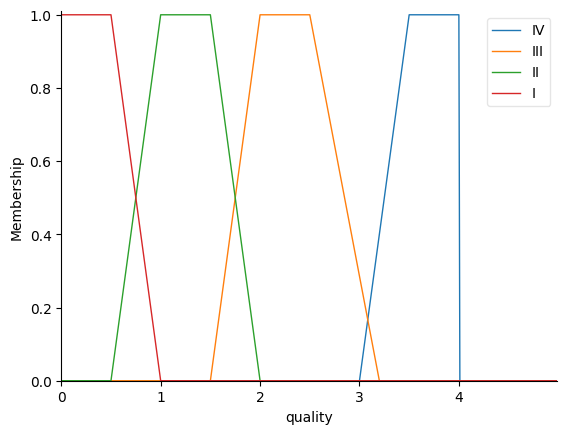

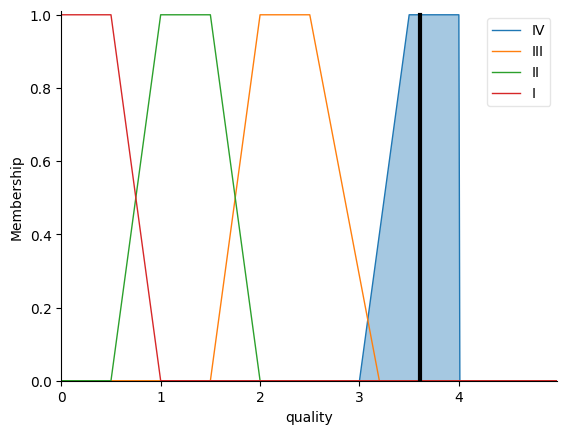

In [25]:
#Definition of input and output variables
size = ctrl.Antecedent(np.arange(300,601,0.01),'size')
defects = ctrl.Antecedent(np.arange(0,20,0.01),'defects')
flavor = ctrl.Antecedent(np.arange(0,1,0.001),'flavor')
quality = ctrl.Consequent(np.arange(0,5,0.01),'quality')

# Definition of input membership functions
size['4'] = fuzz.trapmf(size.universe,[300,315,335,350])
size['3'] = fuzz.trapmf(size.universe,[340,370,420,450])
size['2'] = fuzz.trapmf(size.universe,[420,470,500,550])
size['1'] = fuzz.trapmf(size.universe,[500,520,600,600])
size.view()

defects['a-'] = fuzz.trapmf(defects.universe,[0,0.5,1,1.5])
defects['a'] = fuzz.trapmf(defects.universe,[1,3,4,5])
defects['a+'] = fuzz.trapmf(defects.universe,[4.5,10,20,20])
defects.view()

flavor['sweet'] = fuzz.trapmf(flavor.universe,[0,0,0.5,1])
flavor['acid'] = fuzz.trapmf(flavor.universe,[0.75,1,1,1])
flavor.view()

# Definition of the output membership function
quality['IV'] = fuzz.trapmf(quality.universe,[3,3.5,4,4])
quality['III'] = fuzz.trapmf(quality.universe,[1.5,2,2.5,3.2])
quality['II'] = fuzz.trapmf(quality.universe,[0.5,1,1.5,2])
quality['I'] = fuzz.trapmf(quality.universe,[0,0,0.5,1])
quality.view()

# Fuzzy rules
rule1=ctrl.Rule(size['4']|defects['a-']&flavor['sweet'],quality['IV'])
rule2=ctrl.Rule(size['4']&defects['a-']&flavor['acid'],quality['IV'])
rule3=ctrl.Rule(size['4']&defects['a']&flavor['sweet'],quality['IV'])
rule4=ctrl.Rule(size['4']&defects['a']&flavor['acid'],quality['IV'])
rule5=ctrl.Rule(size['4']&defects['a+']&flavor['sweet'],quality['IV'])
rule6=ctrl.Rule(size['4']&defects['a+']&flavor['acid'],quality['IV'])
rule7=ctrl.Rule(size['3']&defects['a-']&flavor['sweet'],quality['III'])
rule8=ctrl.Rule(size['3']&defects['a-']&flavor['acid'],quality['IV'])
rule9=ctrl.Rule(size['3']&defects['a']&flavor['sweet'],quality['IV'])
rule10=ctrl.Rule(size['3']&defects['a']&flavor['acid'],quality['IV'])
rule11=ctrl.Rule(size['3']&defects['a+']&flavor['sweet'],quality['IV'])
rule12=ctrl.Rule(size['3']&defects['a+']&flavor['acid'],quality['IV'])
rule13=ctrl.Rule(size['2']&defects['a-']&flavor['sweet'],quality['II'])
rule14=ctrl.Rule(size['2']&defects['a-']&flavor['acid'],quality['II'])
rule15=ctrl.Rule(size['2']&defects['a']&flavor['sweet'],quality['III'])
rule16=ctrl.Rule(size['2']&defects['a']&flavor['acid'],quality['IV'])
rule17=ctrl.Rule(size['2']&defects['a+']&flavor['sweet'],quality['IV'])
rule18=ctrl.Rule(size['2']&defects['a+']&flavor['acid'],quality['IV'])
rule19=ctrl.Rule(size['1']&defects['a-']&flavor['sweet'],quality['I'])
rule20=ctrl.Rule(size['1']&defects['a-']&flavor['acid'],quality['I'])
rule21=ctrl.Rule(size['1']&defects['a']&flavor['sweet'],quality['I'])
rule22=ctrl.Rule(size['1']&defects['a']&flavor['acid'],quality['II'])
rule23=ctrl.Rule(size['1']&defects['a+']&flavor['sweet'],quality['II'])
rule24=ctrl.Rule(size['1']&defects['a+']&flavor['acid'],quality['III'])

# Fuzzy Expert System Results
type_ctrl = ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule6,rule7,rule8,rule9,rule10,rule11,rule12,	rule13,	rule14,	rule15,	rule16,	rule17,	rule18,	rule19,	rule20,	rule21,	rule22,	rule23,	rule24])
type = ctrl.ControlSystemSimulation(type_ctrl)
v_size = type.input['size']=int(input('Size of the fruit (300-600g):'))
v_defects = type.input['defects']=float(input('Defects area pf the piece of fruits (0-20cm2):'))
v_flavor = type.input['flavor']=float(input('Fruit flavor (0-1):'))

type.input['size'] = v_size
type.input['defects'] = v_defects
type.input['flavor'] = v_flavor

type.compute()

print('Size of the fruit (300-600g):', v_size)
print('Defects area pf the piece of fruits (0-20cm2):', v_defects)
print('Fruit flavor (0-1):', v_flavor)

print('Fruit quality (between 1 and 4): ', str(round(float(type.output['quality']), 2)))
quality.view(sim=type)

# Termostato (adaptación del ejercicio del tema anterior)

Thermostat setting: -0.7178321819474446


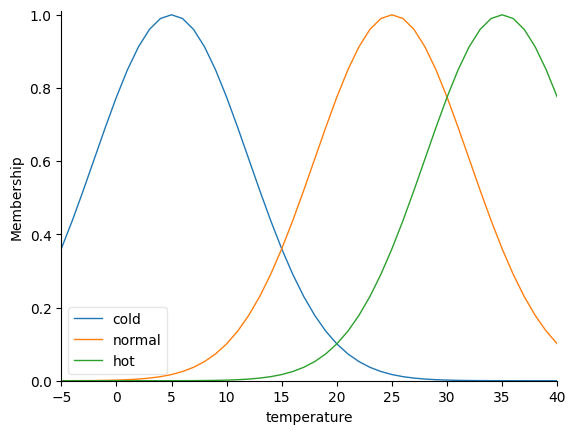

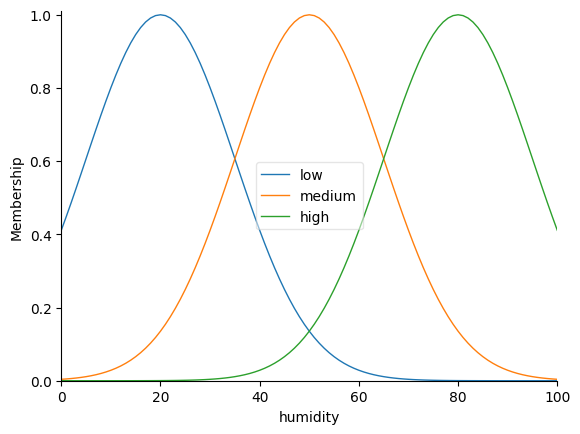

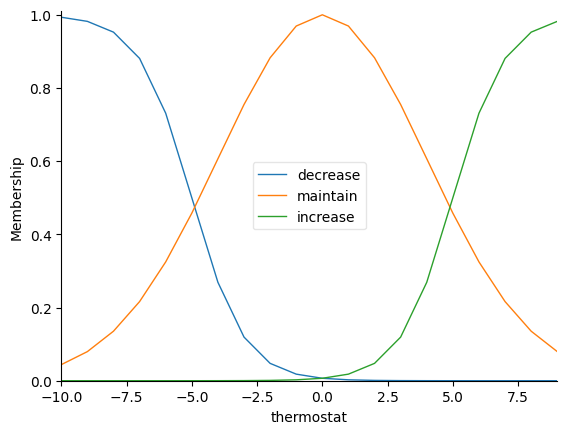

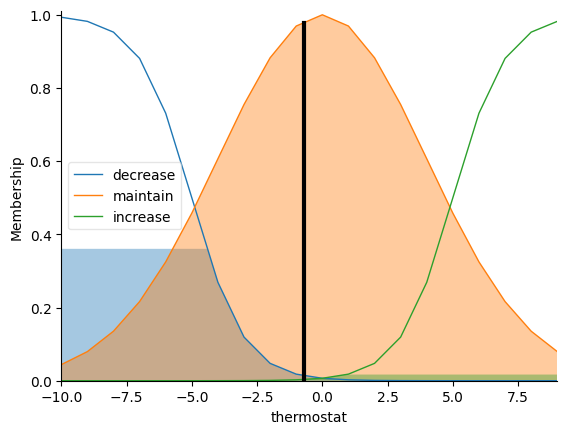

In [26]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Definition of input and output variables
temperature = ctrl.Antecedent(np.arange(-5, 41, 1), 'temperature')
humidity = ctrl.Antecedent(np.arange(0, 101, 1), 'humidity')
thermostat = ctrl.Consequent(np.arange(-10, 10, 1), 'thermostat')

# Definition of input membership functions for temperature
temperature['cold'] = fuzz.gaussmf(temperature.universe, 5, 7)  # Smooth peak around 5
temperature['normal'] = fuzz.gaussmf(temperature.universe, 25, 7)  # Smooth peak around 25
temperature['hot'] = fuzz.gaussmf(temperature.universe, 35, 7)  # Smooth peak around 35
temperature.view()

# Definition of input membership functions for humidity
humidity['low'] = fuzz.gaussmf(humidity.universe, 20, 15)  # Smooth peak around 20
humidity['medium'] = fuzz.gaussmf(humidity.universe, 50, 15)  # Smooth peak around 50
humidity['high'] = fuzz.gaussmf(humidity.universe, 80, 15)  # Smooth peak around 80
humidity.view()

# Definition of output membership functions for thermostat control
thermostat['decrease'] = fuzz.sigmf(thermostat.universe, -5, -1)  # L-shaped for decrease
thermostat['maintain'] = fuzz.gaussmf(thermostat.universe, 0, 4)  # Wide Gaussian for maintain
thermostat['increase'] = fuzz.sigmf(thermostat.universe, 5, 1)  # L-shaped for increase
thermostat.view()

# Definition of fuzzy rules
rule1 = ctrl.Rule(temperature['cold'], thermostat['increase'])
rule2 = ctrl.Rule(temperature['normal'] & ~humidity['high'], thermostat['maintain'])
rule3 = ctrl.Rule(temperature['hot'] | humidity['high'], thermostat['decrease'])

# Fuzzy control system and simulation setup
thermostat_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
type = ctrl.ControlSystemSimulation(thermostat_ctrl)
type.input['temperature'] = int(input('Temperature: '))
type.input['humidity'] = int(input('Humidity: '))
type.compute()
print('Thermostat setting:', type.output['thermostat'])
thermostat.view(sim=type)


# Ejercicio: Sistema de Evaluación de Riesgo de Crédito
Contexto: Un banco local desea automatizar la evaluación preliminar de solicitudes de crédito para pequeños emprendedores. En lugar de un "sí" o "no" rotundo, quieren un sistema que califique el "Nivel de Riesgo" del solicitante basándose en tres factores críticos.

1. Variables de Entrada (Antecedentes)
Deberéis definir tres variables de entrada usando ctrl.Antecedent:

Puntaje Crediticio (0 - 1000 puntos):

    Bajo: [0, 0, 300, 450]

    Medio: [400, 500, 600, 700]

    Alto: [650, 800, 1000, 1000]

Ingresos Mensuales (0 - 10000 €):

    Precarios: [0, 0, 1000, 2000]

    Estables: [1500, 3000, 5000, 7000]

    Elevados: [6000, 8000, 10000, 10000]

Préstamo Solicitado (0 - 50000 €):

    Pequeño: [0, 0, 5000, 15000]

    Grande: [10000, 25000, 50000, 50000]

Variable de Salida (Consecuente)
Nivel de Riesgo (0 a 10):

    Mínimo (I): [0, 0, 1, 2.5]

    Moderado (II): [2, 4, 6, 7]

    Alto (III): [6, 8, 9, 10]

    Crítico (IV): [8.5, 9.5, 10, 10]

1. Programación: Implementar el sistema utilizando la librería skfuzzy (tal como en el ejemplo del fruto).

2. Lógica de Reglas: Crear al menos 10 reglas lógicas. Por ejemplo:

    Si el puntaje es "Bajo" O el ingreso es "Precario", entonces el riesgo es "Crítico".

    Si el puntaje es "Alto" Y el préstamo es "Pequeño", entonces el riesgo es "Mínimo".

3. Simulación: El programa debe pedir por consola los datos del cliente y devolver el nivel de riesgo redondeado a dos decimales.

4. Visualización: Mostrar las gráficas de las funciones de membresía y el resultado de la activación de reglas tras la computación.